## Useful Sources

* PyTorch Crash Course: https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html
* General Overview of Convolutional Neural Networks: https://medium.com/@nikitamalviya/convolution-pooling-f8e797898cf9
* CNN in PyTorch:
*   Heatmap Implementation: https://medium.com/intelligentmachines/implementation-of-class-activation-map-cam-with-pytorch-c32f7e414923





## Uploading Data
Running this block of code should let you browse for the zip file containing our data (this may take a while)

It's easier to drag and drop zip file from computer files



In [ ]:
from google.colab import files as f

zip_data = f.upload_file('images.zip')

Saved images.zip to /content/images.zip


In [ ]:
# Hides output. Otherwise, we'll see 10000 lines of output
%%capture
!unzip skin_cancer_dataset.zip

## Necessary Imports

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
# All of the PyTorch imports we'll use for the neural network
import torch
import torchvision.models as models
import torchvision as tv
import torchvision.transforms as T
import torchvision.datasets as ds
import torch.utils.data as D
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as op


## Device
Sets which device we use. For training and testing, we want to ensure
we are using CUDA.

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
device

'cuda'

## Transformations
Here we define what transformations to perform on each image. The data is already well-defined, so the only thing we need to do is transform each image into a tensor.

In [ ]:
# .Compose() is used to add additional transformations, if needed
transform = T.Compose([
    T.ToTensor(),
])

## Split data into Train and Test sets
Makes use of ImageFolder() to load data into sets where images are already split into folders representing their classes. Each set contains a tuple of the image tensor and its label (0 = benign, 1 = melanoma)

In [ ]:
train_set = ds.ImageFolder("melanoma_cancer_dataset/train", transform)
test_set = ds.ImageFolder("melanoma_cancer_dataset/test", transform)
print(len(train_set))
print(len(test_set))

9605
1000


## See a random image
To ensure data sets were appropriately imported, this just picks a random image and displays it along with its class.


In [ ]:
import random

def randomImage():
  # Picks a random image out of all 10605 images
  img_index = random.randint(0,10604)

  # Image 9605 marks the first of the testing set
  if img_index >= 9605:
    image, label = test_set[img_index - 9605]
  else:
    image, label = train_set[img_index]

  # Converts PyTorch tensor to a PIL image
  return (image, label)

## DataLoaders
Create the dataloader objects, an iterative object allowing PyTorch to train and test with. We define the batch size and number of workers, both of which are "best guesses"

In [ ]:
# How many images to train on before updating weights and reporting accuracy and loss
batch_size = 16

# How many workers "load" data into the model for training simulatenously
num_workers = 2

# Create DataLoaders. True/False refers to shuffle
trainloader = D.DataLoader(train_set, batch_size, True, num_workers = num_workers)
testloader = D.DataLoader(test_set, batch_size, False, num_workers = num_workers)

## Define the Neural Network

In [ ]:
# This defines our neural network
class NeuralNet(nn.Module):

  # All layers are defined here
  # For each tensor, N is the batch size (currently 16)
  def __init__(self):
    super().__init__()

    # Converts input image into a tensor (N, 16, 296, 296)
    self.conv1 = nn.Conv2d(3, 16, 5)

    # 2x2 max pooling layer
    self.pool = nn.MaxPool2d(2)

    # Input channels: 16. Output channels: 64
    # Output tensor (N, 64, 144, 144)
    self.conv2 = nn.Conv2d(16, 64, 5)

    # Input channels: 64. Output channels: 128
    # Output tensor (N, 128, 70, 70)
    self.conv3 = nn.Conv2d(64, 128, 3)

    # Input channels: 128. Output channels: 256
    # Output tensor (N, 256, 34, 34)
    self.conv4 = nn.Conv2d(128, 256, 2)

    # Input channels: 256. Output channels: 512
    # Output tensor (N, 512, 16, 16)
    self.conv5 = nn.Conv2d(256, 512, 2)

    # Flattens tensor into a 2D tensor (N, 512 * 8 * 8)
    self.flatten = nn.Flatten()

    # Reduces dimensions of the features extracted from the convolutional layer
    # into a prediction
    self.fc1 = nn.Linear(512 * 8 * 8, 4096)
    self.fc2 = nn.Linear(4096, 512)
    self.fc3 = nn.Linear(512, 64)
    self.out = nn.Linear(64, 2)


  def forward(self, input):
    # Run first convolutional layer, then run the ReLU activation function
    c1 = F.relu(self.conv1(input))

    # Pooling layer. (N, 16, 296, 296) --> (N, 16, 148, 148)
    p1 = self.pool(c1)

    # Second convolutional layer, then run ReLU activation function
    c2 = F.relu(self.conv2(p1))

    # Pooling layer. (N, 64, 144, 144) --> (N, 64, 72, 72)
    p2 = self.pool(c2)

    # Third CL, then run ReLU
    c3 = F.relu(self.conv3(p2))

    # Pooling layer. (N, 128, 70, 70) --> (N, 128, 35, 35)
    p3 = self.pool(c3)

    # Fourth CL, then run ReLU
    c4 = F.relu(self.conv4(p3))

    # Pooling layer. (N, 256, 34, 34) --> (N, 256, 17, 17)
    p4 = self.pool(c4)

    # Last CL
    c5 = F.relu(self.conv5(p4))

    # Last pooling layer. (N, 512, 16, 16) --> (N, 512, 8, 8)
    p5 = self.pool(c5)

    # Flatten. (N, 512, 8, 8) --> (N, 512 * 8 * 8)
    f1 = self.flatten(p5)

    # Four fully connected layers convert this flattened tensor into a prediction
    # Tensors: (N, 512 * 8 * 8) --> (N, 4096) --> (N, 512) --> (N, 64) --> (N, 2)
    f2 = F.relu(self.fc1(f1))
    f3 = F.relu(self.fc2(f2))
    f4 = F.relu(self.fc3(f3))
    output = F.relu(self.out(f4))

    return output


# Create an instance of our neural network
net = NeuralNet()
net.to(device)
# Show all layers
print(net)

# See the number of parameters
params = list(net.parameters())
print(len(params))

NeuralNet(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 64, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(2, 2), stride=(1, 1))
  (conv5): Conv2d(256, 512, kernel_size=(2, 2), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=4096, bias=True)
  (fc2): Linear(in_features=4096, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=2, bias=True)
)
18


In [ ]:
net = models.resnet18(pretrained=False)
net.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Define Loss function, Optimization function, and learning rate
We will use binary cross-entropy loss and the Adam optimization functions. Adam is a more efficient gradient-descent

In [ ]:
# Our loss function, cross-entropy
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = op.Adam(net.parameters(), lr=0.0001)

## Training Loop
Defines what happens over one epoch:
1. iterates over training data in batches
2. for each batch, pass it thru the model
3. calculate loss and accuracy
4. backpropogate with optimizer to adjust weights
5. report loss and accuracy (every 50 iterations, or so)

In [ ]:
def train_epoch():
  # States we are training the network, so allow parameters to be adjusted
  net.train(True)

  running_loss = 0.0
  running_accuracy = 0.0

  print('-------------------------------Training-------------------------------\n')
  # The loop
  for batch, data in enumerate(trainloader):
    # Load data into appropriate device
    inputs, labels = data[0].to(device), data[1].to(device)
    # Sets gradient to zero
    optimizer.zero_grad()

    # Runs neural network on a training batch
    outputs = net(inputs)

    # Calculates accuracy
    correct = torch.sum(labels == torch.argmax(outputs, dim=1)).item()
    running_accuracy += correct / batch_size

    # Calculates loss
    loss = criterion(outputs, labels)
    running_loss += loss.item()

    # Backpropogation to adjust weights
    loss.backward()
    optimizer.step()

    # Prints our running loss and accuracy every N batches
    report_batch = 60
    if batch % report_batch == report_batch - 1:
      avg_loss = running_loss / report_batch
      avg_accuracy = running_accuracy / report_batch * 100

      print('Batch {0}, Loss: {1:.3f}, Accuracy: {2:.1f}%'.format(batch+1, avg_loss, avg_accuracy))

      running_loss = 0.0
      running_accuracy = 0.0


## Testing Loop
1. iterate over testing data in batches
2. pass each batch thru model
3. calculate loss and accuracy

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Creates a nice looking confusion matrix
def make_cm(outputs, y_true):
  # Uses sklearn to create the CM
  cm = confusion_matrix(y_true, outputs)
  plt.figure(figsize=(16,9))
  ax=plt.subplot()
  sns.heatmap(cm, annot=True, fmt='g', ax=ax, annot_kws={"size": 20})
  ax.set_xlabel('Predicted labels',fontsize=25)
  ax.set_ylabel('True labels',fontsize=25)
  ax.set_title('Confusion Matrix for CNN',fontsize=30)
  ax.xaxis.set_ticklabels(['Benign', 'Malignant'], fontsize=20)
  ax.yaxis.set_ticklabels(['Benign', 'Malignant'], fontsize=20)

In [ ]:
def test_epoch(curr_epoch, cm_epoch):
  net.train(False)
  running_loss = 0.0
  running_accuracy = 0.0

  all_outputs = []
  y_true = []
  for i, data in enumerate(testloader):
    # Load data to appropriate device
    inputs, labels = data[0].to(device), data[1].to(device)

    # Does not run back propogation. We are only testing.
    # Calculates loss and accuracy
    with torch.no_grad():
      outputs = net(inputs)
      y_true.append(labels.cpu().detach().numpy())
      correct = torch.sum(labels == torch.argmax(outputs, dim=1)).item()

      # Compiles all predictions made by the model
      all_outputs.append(torch.argmax(outputs, dim=1).cpu().detach().numpy())

      running_accuracy += correct / batch_size
      loss = criterion(outputs, labels)
      running_loss += loss.item()

  # Makes a long list of both predictions and true values
  all_outputs = np.concatenate(all_outputs, axis=0).squeeze()
  y_true = np.concatenate(y_true, axis=0).squeeze()

  # Construct the matrix if we are on the correct epoch
  if curr_epoch + 1 == cm_epoch:
    make_cm(all_outputs, y_true)

  avg_loss = running_loss / len(testloader)
  avg_accuracy = running_accuracy / len(testloader) * 100
  print('------------------------------Testing---------------------------------\n')
  print('Loss: {0:.3f}, Accuracy: {1:.1f}%'.format(avg_loss, avg_accuracy))

## Train and Test for multiple generations (epochs)
more epochs means more training. we test after each training epoch to see our progress. Ideally, testing accuracy improves, but because we generalize over training data, this is not guaranteed

*******************************Epoch: 1*******************************

-------------------------------Training-------------------------------

Batch 60, Loss: 2.188, Accuracy: 76.5%
Batch 120, Loss: 0.593, Accuracy: 84.3%
Batch 180, Loss: 0.385, Accuracy: 85.8%
Batch 240, Loss: 0.407, Accuracy: 84.0%
Batch 300, Loss: 0.370, Accuracy: 85.1%
Batch 360, Loss: 0.329, Accuracy: 87.3%
Batch 420, Loss: 0.325, Accuracy: 85.7%
Batch 480, Loss: 0.295, Accuracy: 87.8%
Batch 540, Loss: 0.304, Accuracy: 88.1%
Batch 600, Loss: 0.299, Accuracy: 87.1%
------------------------------Testing---------------------------------

Loss: 0.287, Accuracy: 87.7%
*******************************Epoch: 2*******************************

-------------------------------Training-------------------------------

Batch 60, Loss: 0.342, Accuracy: 85.7%
Batch 120, Loss: 0.281, Accuracy: 88.9%
Batch 180, Loss: 0.283, Accuracy: 87.8%
Batch 240, Loss: 0.310, Accuracy: 86.6%
Batch 300, Loss: 0.280, Accuracy: 88.8%
Batch 360, Lo

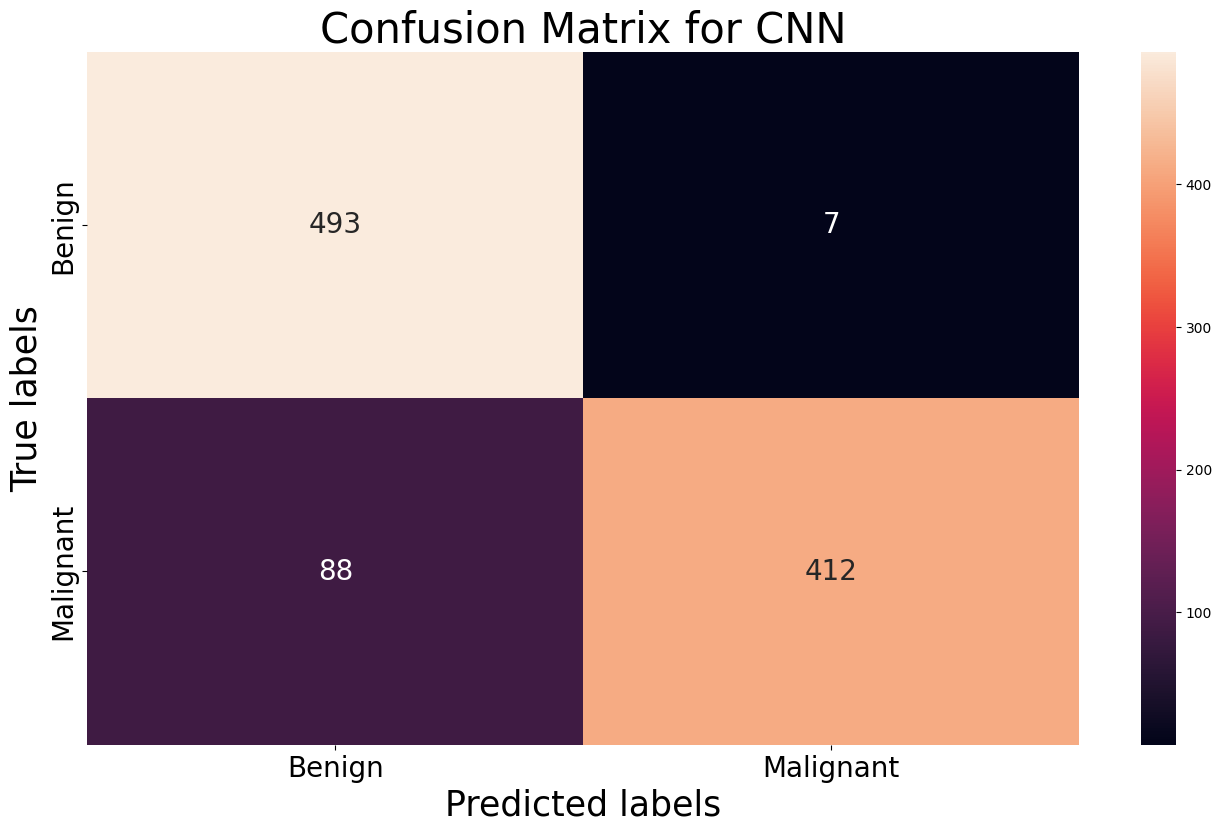

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
  print(f'*******************************Epoch: {epoch + 1}*******************************\n')
  train_epoch()
  test_epoch(epoch, 10)

------------------------------Testing---------------------------------

Loss: 0.215, Accuracy: 90.7%


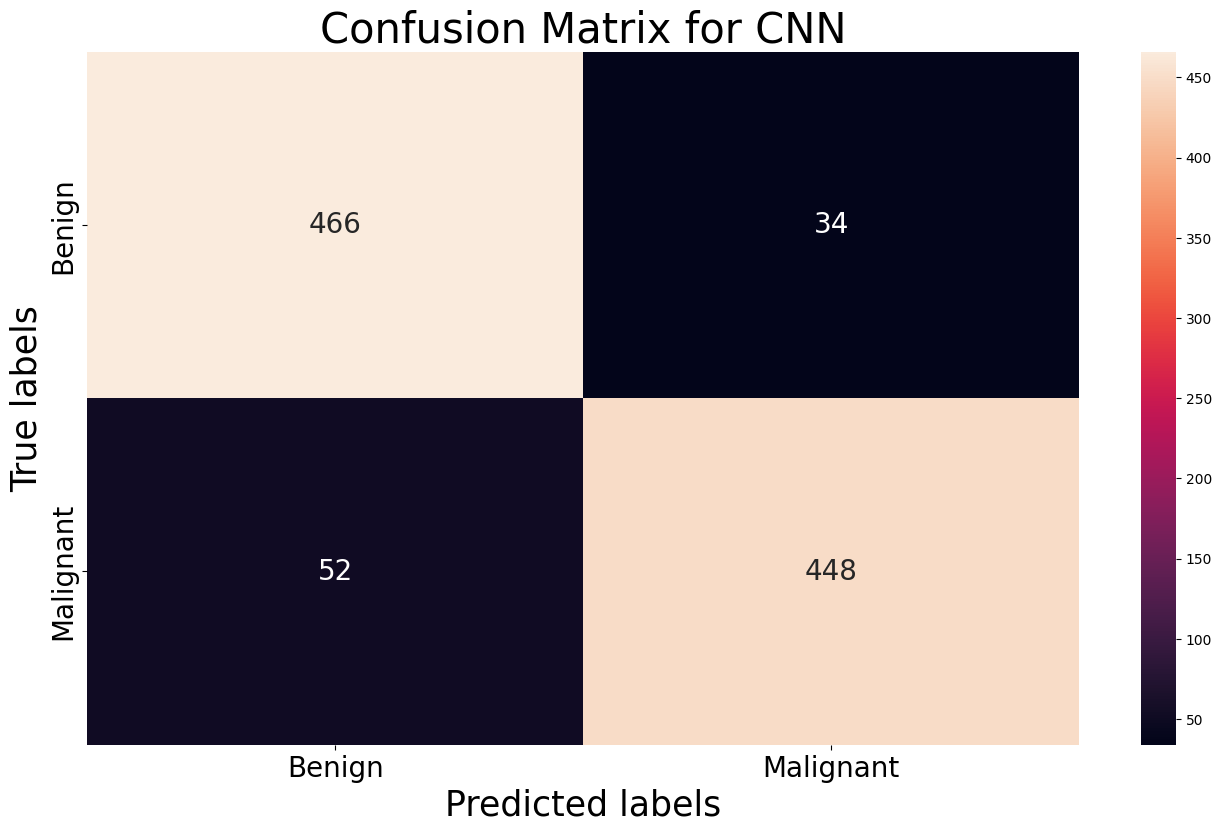

In [ ]:
test_epoch(0,1)

In [ ]:
# Combines all convolutional layers into a list
conv_layers = []
for layer in net.children():
  if isinstance(layer, nn.Conv2d):
    conv_layers.append(layer)
  for child in list(layer.children()):
    for child_layer in child.children():
      if isinstance(child_layer, nn.Conv2d):
        conv_layers.append(child_layer)

conv_layers

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False),
 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False),
 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 Conv2d(256, 256, kernel_siz

1


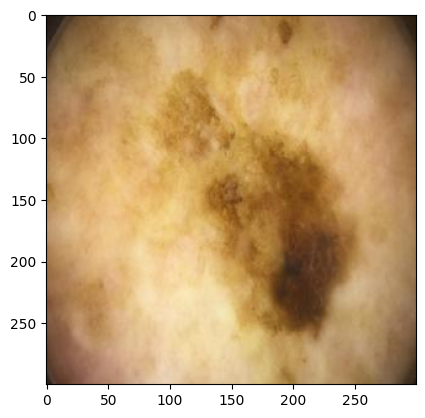

In [ ]:
image, label = randomImage()
image = T.ToPILImage()(image)
plt.imshow(image)
print(label)

In [ ]:
# Makes prediction on the single image
image = transform(image).unsqueeze(0).to(device)
prediction = torch.argmax(net(image)).cpu().detach().numpy()
if prediction == 0:
  print("Benign")
else:
  print("Malignant")

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

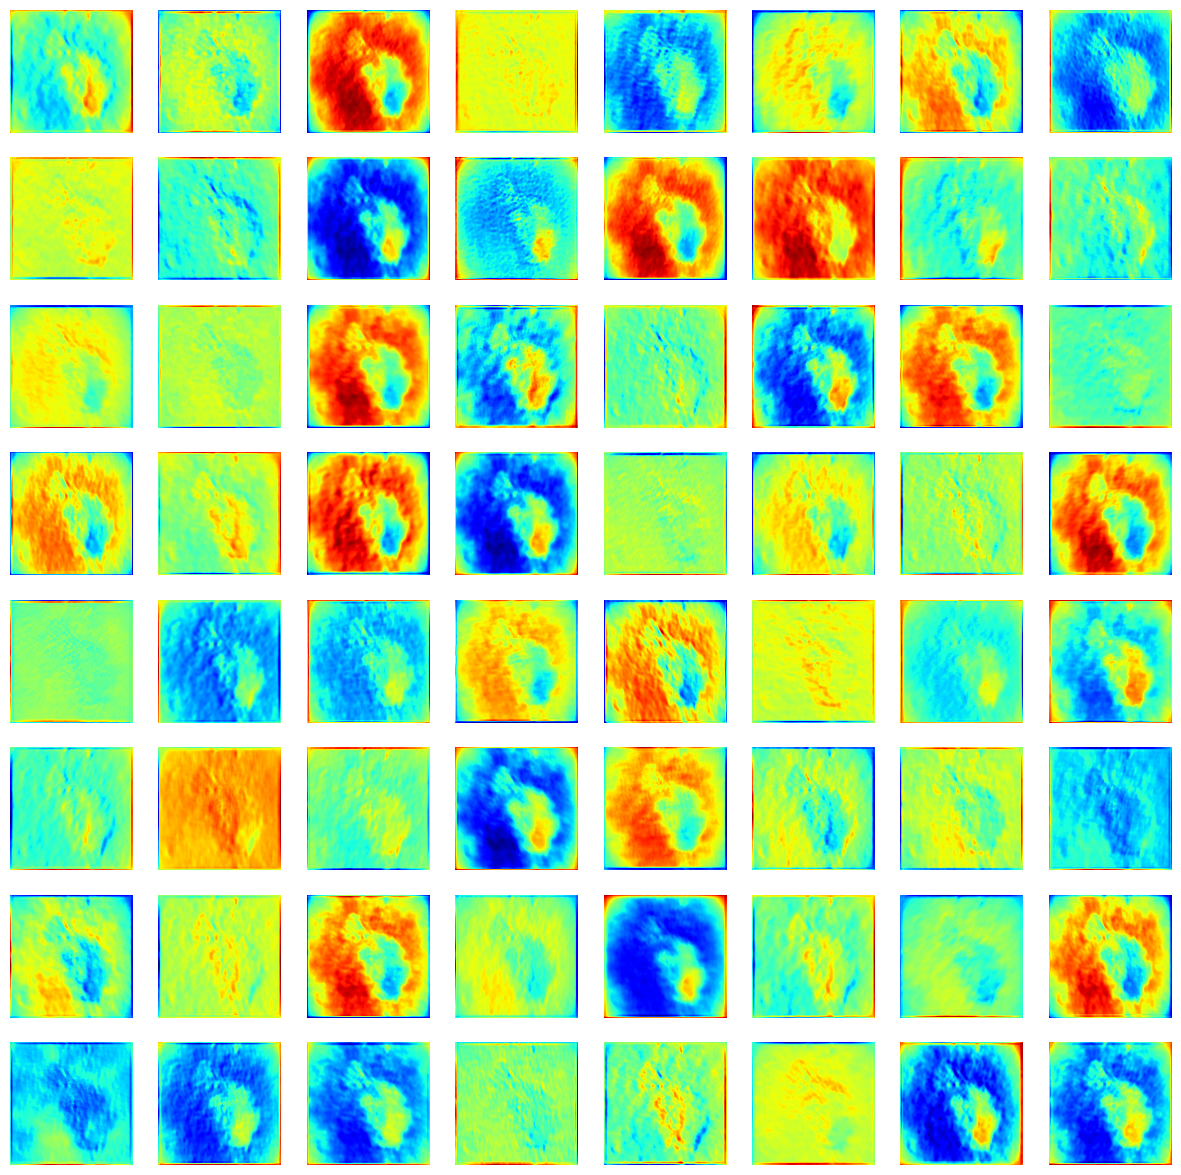

In [ ]:
# Shows the feature maps after 5 convolutional layers (could change this)
results = [conv_layers[0](image)]
for i in range (1, 5):
  results.append(conv_layers[i](results[-1]))

layer_visualize = results[-1].squeeze()
layer_visualize = layer_visualize.detach().cpu().numpy()
plt.figure(figsize=(15,15))
plt.set_cmap('jet')
for i in range(layer_visualize.shape[0]):
  plt.subplot(8, 8, i+1)
  plt.imshow(layer_visualize[i])
  plt.axis('off')